# G'Contest 2026 - Fraud & Anomaly Detection

Notebook này sinh và phân tích bộ dữ liệu synthetic theo đúng data dictionary của đề bài, phân tích nguyên nhân trước, sau đó xây dựng framework hybrid rule-based + Isolation Forest để phát hiện giao dịch bất thường. Dữ liệu synthetic chỉ dùng để minh họa quy trình end-to-end khi chưa có dữ liệu bản ghi thật.

## 1. Setup

In [1]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.append(str(PROJECT_ROOT / 'src'))
from generate_synthetic_data import write_outputs, GenerationConfig
from fraud_pipeline import load_data, validate_schema, build_features, build_rule_score, score_model, assign_top_reasons, evaluate
sns.set_theme(style='whitegrid')
RAW_DIR = PROJECT_ROOT / 'data/raw'
OUTPUT_DIR = PROJECT_ROOT / 'outputs'

## 2. Generate Synthetic Data

In [2]:
config = GenerationConfig(n_customers=3000, target_transactions=150000, target_activities=220000)
write_outputs(config, RAW_DIR)
pd.read_csv(RAW_DIR / 'synthetic_metadata.csv')

,table,rows,columns
0,Data_Customer.csv,3000,12
1,Data_Transaction.csv,150000,13
2,Data_Activity.csv,220000,6
3,Data_Deposit.csv,267000,6
4,Data_Lending.csv,267000,7
5,Data_Card.csv,267000,7
6,synthetic_ground_truth.csv,150000,5


## 3. Load Data And Validate Schema

In [3]:
data = load_data(RAW_DIR)
schema_report = validate_schema(data)
pd.DataFrame(schema_report).T

,rows,missing_columns,extra_columns,null_cells,duplicate_rows
customer,3000,[],[],0,0
transaction,150000,[],[],0,0
activity,220000,[],[],0,0
deposit,267000,[],[],0,0
lending,267000,[],[],0,0
card,267000,[],[],0,0


## 4. Data Quality Snapshot

In [4]:
quality_rows = []
for name, df in data.items():
    quality_rows.append({
        'table': name,
        'rows': len(df),
        'columns': len(df.columns),
        'null_cells': int(df.isna().sum().sum()),
        'duplicate_rows': int(df.duplicated().sum()),
    })
pd.DataFrame(quality_rows)

,table,rows,columns,null_cells,duplicate_rows
0,customer,3000,12,0,0
1,transaction,150000,13,0,0
2,activity,220000,6,0,0
3,deposit,267000,6,0,0
4,lending,267000,7,0,0
5,card,267000,7,0,0
6,truth,150000,5,0,0


## 5. EDA

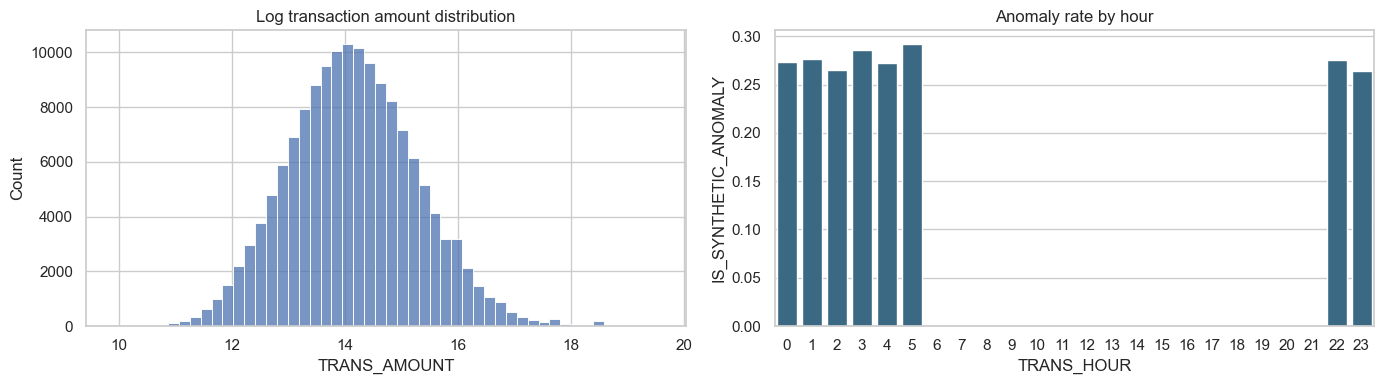

In [5]:
trx = data['transaction'].copy()
truth = data['truth'].copy()
trx.insert(0, 'transaction_row_id', [f'TRX{i:07d}' for i in range(1, len(trx)+1)])
trx = trx.merge(truth, on=['transaction_row_id', 'CUSTOMER_NUMBER'], how='left')
trx['IS_SYNTHETIC_ANOMALY'] = trx['IS_SYNTHETIC_ANOMALY'].fillna(0).astype(int)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(np.log1p(trx['TRANS_AMOUNT']), bins=50, ax=axes[0])
axes[0].set_title('Log transaction amount distribution')
hour_rate = trx.groupby('TRANS_HOUR')['IS_SYNTHETIC_ANOMALY'].mean().reset_index()
sns.barplot(data=hour_rate, x='TRANS_HOUR', y='IS_SYNTHETIC_ANOMALY', ax=axes[1], color='#2F6B8F')
axes[1].set_title('Anomaly rate by hour')
plt.tight_layout()

## 6. Root-Cause Hypothesis Before Modeling

BGK đánh giá cao việc xác định nguyên nhân trước khi đưa model. Framework này gom tín hiệu vào 3 nhánh nguyên nhân:

1. Account access / identity compromise: thiết bị mới, IP mới, OTP, add beneficiary, change password.
2. Abnormal transaction behavior: amount lệch baseline, giao dịch đêm, burst tần suất, dòng tiền ra bất thường.
3. Network / AML linkage: IP/device dùng chung nhiều khách hàng, chuyển khoản ngoài hệ thống, giao dịch số tròn lặp lại.

`ACTIVITY_NO` được đọc như thứ tự hành vi: số nhỏ là bước sớm, số lớn là bước sau/nhạy cảm hơn.

In [6]:
pd.DataFrame({
    'cause_branch': ['Account access / identity compromise', 'Abnormal transaction behavior', 'Network / AML linkage'],
    'signals': [
        'New device/IP, OTP request, add beneficiary, change password',
        'Night transaction, amount above customer P95, daily burst, cash-out vs balance',
        'Shared device/IP, external transfer, round-value repeated transfers',
    ],
    'business_risk': ['Account takeover', 'Unauthorized transfer', 'Money laundering proxy'],
})

,cause_branch,signals,business_risk
0,Account access / identity compromise,"New device/IP, OTP request, add beneficiary, c...",Account takeover
1,Abnormal transaction behavior,"Night transaction, amount above customer P95, ...",Unauthorized transfer
2,Network / AML linkage,"Shared device/IP, external transfer, round-val...",Money laundering proxy


## 7. Feature Engineering

In [7]:
features = build_features(data)
features.shape, features[['TRANS_AMOUNT','amount_zscore_customer','daily_txn_count_ratio','device_customer_count','ip_customer_count','max_activity_no_same_day']].describe().T

((150000, 69),
                              count          mean           std           min  \
 TRANS_AMOUNT              150000.0  2.840453e+06  6.064194e+06  20000.000000   
 amount_zscore_customer    150000.0  1.326346e-18  9.899528e-01     -1.675740   
 daily_txn_count_ratio     150000.0  1.011662e+00  1.500588e-01      0.888889   
 device_customer_count     150000.0  1.119153e+00  1.560491e+00      1.000000   
 ip_customer_count         150000.0  5.093627e+00  1.178382e+01      1.000000   
 max_activity_no_same_day  150000.0  1.083133e-01  6.916633e-01      0.000000   
 
                                     25%           50%           75%  \
 TRANS_AMOUNT              632000.000000  1.342000e+06  2.921250e+06   
 amount_zscore_customer        -0.518704 -2.641216e-01  1.162312e-01   
 daily_txn_count_ratio          0.979592  9.927536e-01  1.000000e+00   
 device_customer_count          1.000000  1.000000e+00  1.000000e+00   
 ip_customer_count              2.000000  3.000000e+00  

## 8. Rule-Based Cause Score

In [8]:
scored = features.merge(data['truth'], on=['transaction_row_id', 'CUSTOMER_NUMBER'], how='left')
scored['IS_SYNTHETIC_ANOMALY'] = scored['IS_SYNTHETIC_ANOMALY'].fillna(0).astype(int)
scored['ANOMALY_TYPE'] = scored['ANOMALY_TYPE'].fillna('NORMAL')
scored = build_rule_score(scored)
scored[['primary_cause_branch','branch_identity_access_score','branch_transaction_behavior_score','branch_network_aml_score','rule_reasons']].head()

,primary_cause_branch,branch_identity_access_score,branch_transaction_behavior_score,branch_network_aml_score,rule_reasons
0,Account access / identity compromise,20.0,0.0,0.0,Không có rule cảnh báo mạnh
1,Network / AML linkage,20.0,0.0,24.0,Thiết bị/IP dùng bởi nhiều khách hàng
2,Account access / identity compromise,20.0,0.0,0.0,Không có rule cảnh báo mạnh
3,Account access / identity compromise,20.0,0.0,0.0,Không có rule cảnh báo mạnh
4,Account access / identity compromise,20.0,0.0,0.0,Không có rule cảnh báo mạnh


## 9. Isolation Forest And Hybrid Score

In [9]:
scored, feature_importance = score_model(scored)
scored = assign_top_reasons(scored, feature_importance)
scored[['transaction_row_id','risk_score_0_100','risk_band','primary_cause_branch','top_reasons']].sort_values('risk_score_0_100', ascending=False).head(10)

,transaction_row_id,risk_score_0_100,risk_band,primary_cause_branch,top_reasons
117583,TRX0117584,94.00,Critical,Network / AML linkage,Giao dịch ngoài khung giờ thông thường; Số tiề...
107147,TRX0107148,93.09,Critical,Network / AML linkage,Giao dịch ngoài khung giờ thông thường; Số tiề...
103279,TRX0103280,91.80,Critical,Network / AML linkage,Giao dịch ngoài khung giờ thông thường; Số tiề...
46071,TRX0046072,91.09,Critical,Network / AML linkage,Giao dịch ngoài khung giờ thông thường; Số tiề...
120423,TRX0120424,89.93,Critical,Network / AML linkage,Giao dịch ngoài khung giờ thông thường; Số tiề...
28822,TRX0028823,89.56,Critical,Network / AML linkage,Giao dịch ngoài khung giờ thông thường; Số tiề...
94280,TRX0094281,88.37,Critical,Network / AML linkage,Giao dịch ngoài khung giờ thông thường; Số tiề...
125854,TRX0125855,88.26,Critical,Network / AML linkage,Giao dịch ngoài khung giờ thông thường; Số tiề...
2902,TRX0002903,88.26,Critical,Network / AML linkage,Giao dịch ngoài khung giờ thông thường; Số tiề...
10169,TRX0010170,88.18,Critical,Network / AML linkage,Giao dịch ngoài khung giờ thông thường; Số tiề...


## 10. Evaluation Against Synthetic Ground Truth

In [10]:
metrics = evaluate(scored)
metrics

{'rows_scored': 150000,
 'synthetic_anomaly_count': 2700,
 'threshold_for_positive': 60,
 'precision_at_threshold': 0.9974,
 'recall_at_threshold': 0.2889,
 'f1_at_threshold': 0.448,
 'confusion_matrix': [[147298, 2], [1920, 780]],
 'average_precision_pr_auc': 0.9597,
 'roc_auc': 0.9992,
 'precision_at_100': 1.0,
 'recall_at_100': 0.037,
 'precision_at_500': 1.0,
 'recall_at_500': 0.1852,
 'precision_at_1000': 0.994,
 'recall_at_1000': 0.3681,
 'precision_at_2500': 0.9308,
 'recall_at_2500': 0.8619,
 'risk_band_distribution': {'Low': 146866,
  'Medium': 2352,
  'High': 669,
  'Critical': 113},
 'top_anomaly_types_in_critical': {'MONEY_LAUNDERING_PROXY': 110,
  'BEHAVIORAL_OUTLIER': 2,
  'ACCOUNT_TAKEOVER': 1},
 'stability_by_period': {'2024-2026 digital acceleration': {'rows': 48624,
   'anomaly_rate': 0.0184,
   'avg_risk_score': 10.3341,
   'high_or_critical_count': 265,
   'precision_at_top_1pct': 0.9959,
   'roc_auc': 0.9992,
   'pr_auc': 0.963},
  '2022-2023 recovery': {'rows': 40

## 11. Stability Across Time

In [11]:
pd.DataFrame.from_dict(metrics['stability_by_period'], orient='index')

,rows,anomaly_rate,avg_risk_score,high_or_critical_count,precision_at_top_1pct,roc_auc,pr_auc
2024-2026 digital acceleration,48624,0.0184,10.3341,265,0.9959,0.9992,0.9630
2022-2023 recovery,40317,0.0190,10.3509,212,0.9826,0.9991,0.9585
2020-2021 crisis,40485,0.0182,10.3073,204,0.9802,0.9992,0.9595
2019 baseline,20574,0.0145,10.6205,101,0.9756,0.9993,0.9565


## 12. Explainability

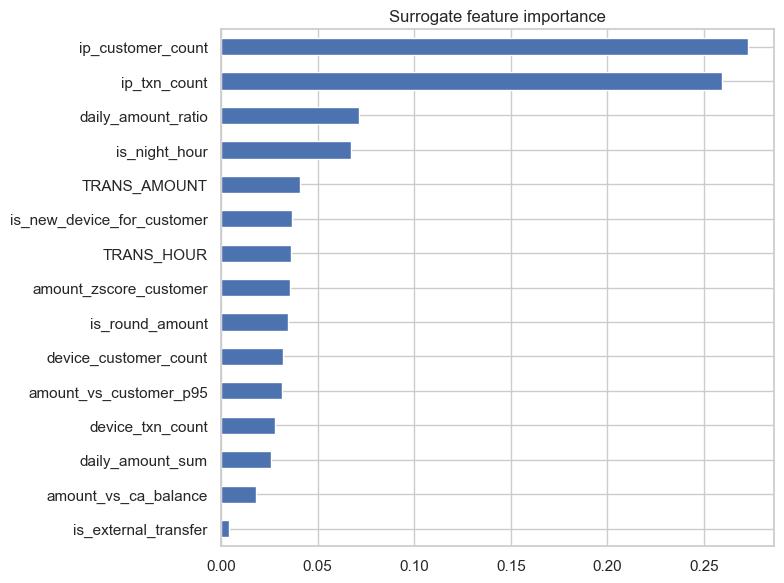

In [12]:
pd.Series(feature_importance).sort_values(ascending=False).head(15).plot(kind='barh', figsize=(8, 6), title='Surrogate feature importance')
plt.gca().invert_yaxis()
plt.tight_layout()

In [13]:
scored.sort_values('risk_score_0_100', ascending=False)[[
    'transaction_row_id','CUSTOMER_NUMBER','TRANS_DATE','TRANS_HOUR','TRANS_AMOUNT',
    'risk_score_0_100','risk_band','primary_cause_branch','ANOMALY_TYPE','top_reasons','recommended_action'
]].head(12)

,transaction_row_id,CUSTOMER_NUMBER,TRANS_DATE,TRANS_HOUR,TRANS_AMOUNT,risk_score_0_100,risk_band,primary_cause_branch,ANOMALY_TYPE,top_reasons,recommended_action
117583,TRX0117584,CUS002645,2021-02-17,23,99000000,94.00,Critical,Network / AML linkage,MONEY_LAUNDERING_PROXY,Giao dịch ngoài khung giờ thông thường; Số tiề...,Block/hold transaction for manual review and A...
107147,TRX0107148,CUS000446,2025-12-29,4,99000000,93.09,Critical,Network / AML linkage,MONEY_LAUNDERING_PROXY,Giao dịch ngoài khung giờ thông thường; Số tiề...,Block/hold transaction for manual review and A...
103279,TRX0103280,CUS002932,2021-01-21,23,99000000,91.80,Critical,Network / AML linkage,MONEY_LAUNDERING_PROXY,Giao dịch ngoài khung giờ thông thường; Số tiề...,Block/hold transaction for manual review and A...
46071,TRX0046072,CUS002218,2020-10-31,4,99000000,91.09,Critical,Network / AML linkage,MONEY_LAUNDERING_PROXY,Giao dịch ngoài khung giờ thông thường; Số tiề...,Block/hold transaction for manual review and A...
120423,TRX0120424,CUS002719,2022-12-18,22,99000000,89.93,Critical,Network / AML linkage,MONEY_LAUNDERING_PROXY,Giao dịch ngoài khung giờ thông thường; Số tiề...,Block/hold transaction for manual review and A...
28822,TRX0028823,CUS001695,2023-08-28,23,99000000,89.56,Critical,Network / AML linkage,MONEY_LAUNDERING_PROXY,Giao dịch ngoài khung giờ thông thường; Số tiề...,Block/hold transaction for manual review and A...
94280,TRX0094281,CUS000449,2023-09-17,22,99000000,88.37,Critical,Network / AML linkage,MONEY_LAUNDERING_PROXY,Giao dịch ngoài khung giờ thông thường; Số tiề...,Block/hold transaction for manual review and A...
125854,TRX0125855,CUS001195,2025-05-30,22,99000000,88.26,Critical,Network / AML linkage,MONEY_LAUNDERING_PROXY,Giao dịch ngoài khung giờ thông thường; Số tiề...,Block/hold transaction for manual review and A...
2902,TRX0002903,CUS002301,2025-07-08,0,99000000,88.26,Critical,Network / AML linkage,MONEY_LAUNDERING_PROXY,Giao dịch ngoài khung giờ thông thường; Số tiề...,Block/hold transaction for manual review and A...
10169,TRX0010170,CUS000394,2024-03-24,2,99000000,88.18,Critical,Network / AML linkage,MONEY_LAUNDERING_PROXY,Giao dịch ngoài khung giờ thông thường; Số tiề...,Block/hold transaction for manual review and A...


## 13. Business Recommendations And Live Demo Idea

- Low/Medium risk: tiếp tục theo dõi và so sánh với baseline khách hàng.
- High risk: áp dụng step-up authentication hoặc near-real-time review.
- Critical risk: giữ giao dịch để manual review; nếu lặp theo IP/device/beneficiary thì chuyển AML escalation.
- Có thể demo bằng `src/customer_risk_advisor.py`: nhập `CUSTOMER_NUMBER` hoặc `transaction_row_id`, hệ thống trả dự báo, root cause và action.
- KPI vận hành: Precision@K, recall@K trên case đã review, false-positive rate theo phân khúc, số case/ngày.